# Modelado de Churn: del modelo a la decisión óptima

**Hackathon 3 — Telco Customer Churn (IBM)**

Este notebook resuelve el problema completo: desde el planteamiento del problema de ML hasta la decisión de negocio de a qué clientes intervenir, bajo la restricción de que solo se puede intervenir al **20%** de los clientes (costo de intervención: 10, valor de retención: 100).

Ver `DECISIONES.md` para la justificación extendida de cada decisión.

## 1. Planteamiento del problema

- **Variable objetivo:** `Churn` (Yes/No) → se codifica como `ChurnFlag` (1/0).
- **Tipo de modelo:** clasificador binario cuya salida útil es la **probabilidad** de churn (`predict_proba`), no solo la clase, porque la decisión de negocio necesita **rankear** clientes por riesgo bajo un presupuesto fijo (20% de la base).
- **Métricas de modelo:** ROC-AUC, PR-AUC (más informativa que ROC-AUC con ~26.5% de positivos), Precision/Recall en el top-20%, Brier score (calibración de probabilidades).
- **Métrica de negocio (la que realmente decide):** `Profit = 100 * retenidos_correctamente - 10 * intervenidos`.
- El objetivo **no** es maximizar accuracy: un modelo con alto accuracy que ignore a los clientes de alto riesgo es inútil para esta decisión.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    brier_score_loss, roc_curve, precision_recall_curve, confusion_matrix
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

pd.set_option("display.max_columns", 50)

## 2. Carga y limpieza de datos

`TotalCharges` viene tipada como texto porque 11 filas tienen un string vacío (`" "`) — corresponden exactamente a clientes con `tenure == 0` (clientes nuevos, sin facturación acumulada aún). Se convierten a `NaN` y se imputan con `0.0` (consistente con "aún no se les ha facturado nada"), en vez de eliminarlas, para no perder señal de esos clientes de tenure 0 (que suelen ser un segmento de alto riesgo de churn).

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# TotalCharges: blank strings -> NaN -> 0.0 (tenure == 0 customers)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")
assert (df["TotalCharges"].isna() == (df["tenure"] == 0)).all(), \
    "Expected TotalCharges NaNs to align exactly with tenure == 0"
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

# Target
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)

# customerID has no predictive value
df = df.drop(columns=["customerID"])

assert df.isnull().sum().sum() == 0, "Unexpected remaining nulls after cleaning"
print("Churn rate:", df["ChurnFlag"].mean().round(4))
df.info()

Churn rate: 0.2654
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 

## 3. Análisis exploratorio de datos (EDA)

Objetivo: entender el desbalance de clases, qué variables numéricas y categóricas separan mejor a los clientes que hacen churn, y detectar problemas de datos adicionales antes de modelar.

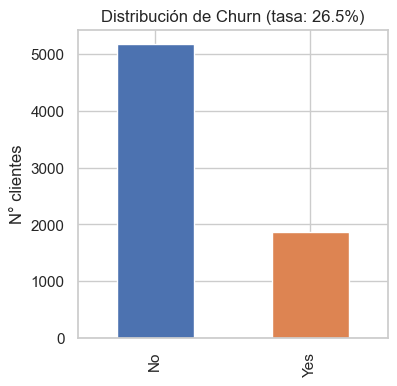

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))
df["Churn"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title(f"Distribución de Churn (tasa: {df['ChurnFlag'].mean():.1%})")
ax.set_xlabel("")
ax.set_ylabel("N° clientes")
plt.show()

**Desbalance moderado (~26.5% churn, ~73.5% no-churn).** No es extremo, pero sí suficiente para que accuracy sea engañosa (un modelo que siempre predice "No churn" ya obtendría ~73.5% de accuracy). Se usará `class_weight='balanced'` / `scale_pos_weight` y métricas basadas en ranking (PR-AUC, profit) en vez de accuracy.

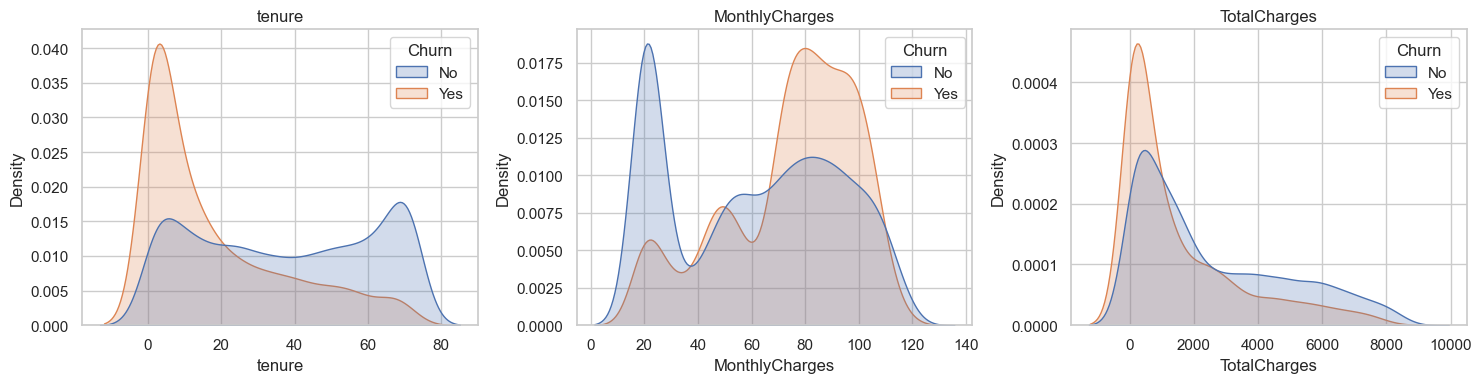

In [5]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df, x=col, hue="Churn", fill=True, common_norm=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

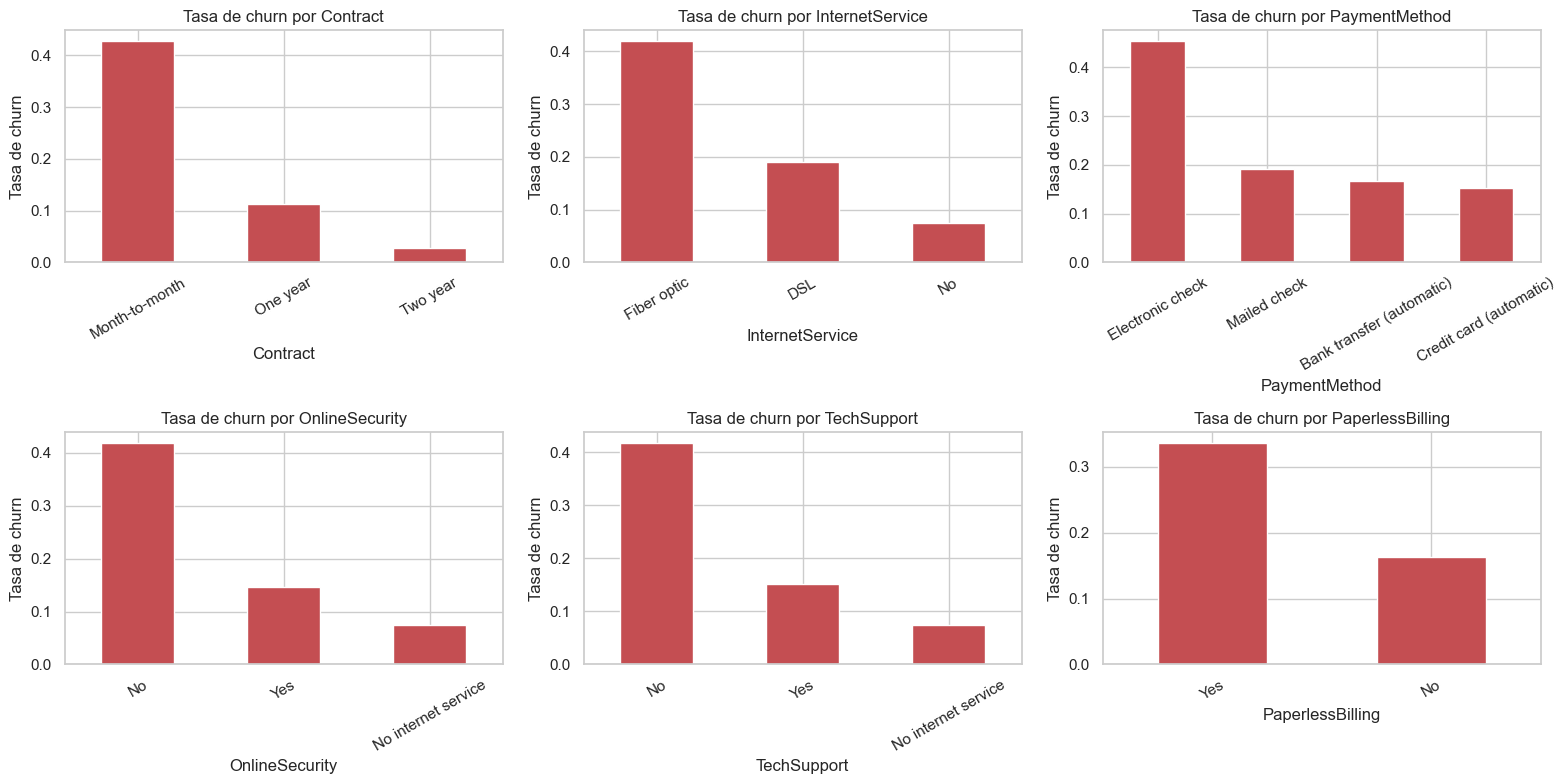

In [6]:
cat_cols_of_interest = ["Contract", "InternetService", "PaymentMethod",
                         "OnlineSecurity", "TechSupport", "PaperlessBilling"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), cat_cols_of_interest):
    rate = df.groupby(col)["ChurnFlag"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#C44E52")
    ax.set_title(f"Tasa de churn por {col}")
    ax.set_ylabel("Tasa de churn")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

`Contract` (month-to-month vs. anual/bianual) y `tenure` bajo muestran consistentemente la señal más fuerte, junto con `InternetService=Fiber optic` y ausencia de `OnlineSecurity`/`TechSupport` — coherente con el comportamiento típico de este dataset público.

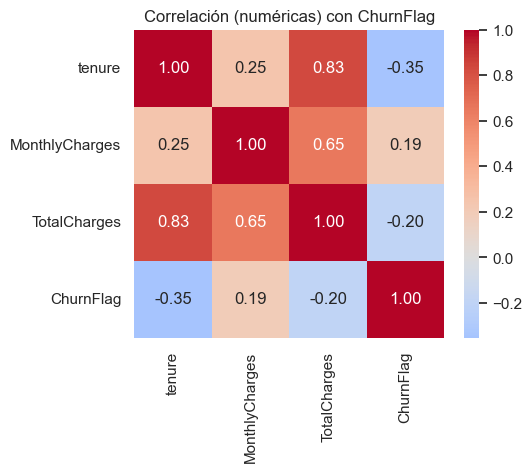

In [7]:
corr = df[numeric_cols + ["ChurnFlag"]].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación (numéricas) con ChurnFlag")
plt.show()

## 4. Pipeline de preprocesamiento

Construido desde cero con `ColumnTransformer` + `Pipeline` de scikit-learn (sin AutoML). Todo el preprocesamiento se ajusta (`fit`) únicamente sobre train, dentro del pipeline, para evitar fuga de información (data leakage) hacia test.

- **Numéricas** (`tenure`, `MonthlyCharges`, `TotalCharges`): imputación por mediana (robusta a outliers) + `StandardScaler` (requerido por regresión logística; inocuo para los modelos de árbol).
- **Categóricas** (el resto, incl. `SeniorCitizen` tratada como categórica binaria): `OneHotEncoder(handle_unknown='ignore')`, para que categorías no vistas en producción no rompan el pipeline.
- **Split:** 80/20 estratificado por `Churn`, para preservar la proporción ~26.5%/~73.5% en ambos conjuntos.

In [8]:
target = "ChurnFlag"
drop_cols = ["Churn", target]

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [c for c in df.columns if c not in numeric_features + drop_cols]

X = df.drop(columns=drop_cols)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

print("Train:", X_train.shape, "churn rate:", y_train.mean().round(4))
print("Test :", X_test.shape, "churn rate:", y_test.mean().round(4))
assert abs(y_train.mean() - y_test.mean()) < 0.02, "Stratified split should preserve churn rate"

Train: (5634, 19) churn rate: 0.2654
Test : (1409, 19) churn rate: 0.2654


## 5. Modelado

Se comparan tres modelos sobre el mismo pipeline y split, para poder justificar la elección final con evidencia y no por defecto:

- **Regresión Logística** (`class_weight='balanced'`): baseline lineal, totalmente interpretable (coeficientes = impacto directo por feature), rápida de entrenar y explicar al negocio. Limitación: no captura interacciones no lineales entre variables.
- **Random Forest** (`class_weight='balanced'`): captura interacciones y no linealidades, robusto a outliers/escala, da importancias de features. Limitación: menos interpretable, puede sobreajustar con árboles muy profundos.
- **XGBoost** (`scale_pos_weight` = ratio negativos/positivos): boosting con regularización, suele dar el mejor ranking de probabilidad en datos tabulares como este. Limitación: más hiperparámetros, mayor riesgo de sobreajuste si no se regulariza, algo menos interpretable que Random Forest "out of the box".

**Manejo del desbalance:** se usan pesos de clase (`class_weight` / `scale_pos_weight`) en vez de oversampling (SMOTE). Razón: la decisión final depende de un **ranking de probabilidades** calibradas razonablemente; el oversampling sintético puede distorsionar esas probabilidades, mientras que los pesos de clase solo cambian la función de pérdida en el entrenamiento sin inventar filas.

In [9]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000,
                                    random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                                        class_weight="balanced",
                                        random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("clf", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               scale_pos_weight=scale_pos_weight,
                               eval_metric="logloss", random_state=RANDOM_STATE,
                               n_jobs=-1)),
    ]),
}

proba = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    proba[name] = pipe.predict_proba(X_test)[:, 1]
    print(f"{name}: fitted, mean predicted churn prob on test = {proba[name].mean():.3f}")

Logistic Regression: fitted, mean predicted churn prob on test = 0.416


Random Forest: fitted, mean predicted churn prob on test = 0.405


XGBoost: fitted, mean predicted churn prob on test = 0.389


## 6. Evaluación

Métricas usadas (más allá de accuracy, que aquí es engañosa por el desbalance):

- **ROC-AUC:** discriminación global entre clases.
- **PR-AUC (average precision):** más informativa con clase positiva minoritaria (~26.5%); premia modelos que rankean bien a los pocos positivos, que es justo lo que necesita la decisión de Top-K.
- **Precision@20% / Recall@20%:** directamente atadas a la restricción de negocio (solo se interviene el 20% con mayor score).
- **Brier score:** qué tan bien calibradas están las probabilidades (más bajo = mejor).

In [10]:
def precision_recall_at_k(y_true, y_score, k_frac=0.20):
    n_top = int(np.ceil(len(y_score) * k_frac))
    top_idx = np.argsort(y_score)[::-1][:n_top]
    y_pred_top = np.zeros_like(y_true)
    y_pred_top[top_idx] = 1
    return precision_score(y_true, y_pred_top), recall_score(y_true, y_pred_top)

rows = []
for name in models:
    p20, r20 = precision_recall_at_k(y_test.values, proba[name])
    rows.append({
        "Modelo": name,
        "ROC-AUC": roc_auc_score(y_test, proba[name]),
        "PR-AUC": average_precision_score(y_test, proba[name]),
        "Precision@20%": p20,
        "Recall@20%": r20,
        "Brier": brier_score_loss(y_test, proba[name]),
    })
metrics_df = pd.DataFrame(rows).set_index("Modelo").round(4)
metrics_df

,ROC-AUC,PR-AUC,Precision@20%,Recall@20%,Brier
Modelo,,,,,
Logistic Regression,0.8415,0.6325,0.6596,0.4973,0.1687
Random Forest,0.8420,0.6509,0.6773,0.5107,0.1625
XGBoost,0.8413,0.6556,0.6702,0.5053,0.1611


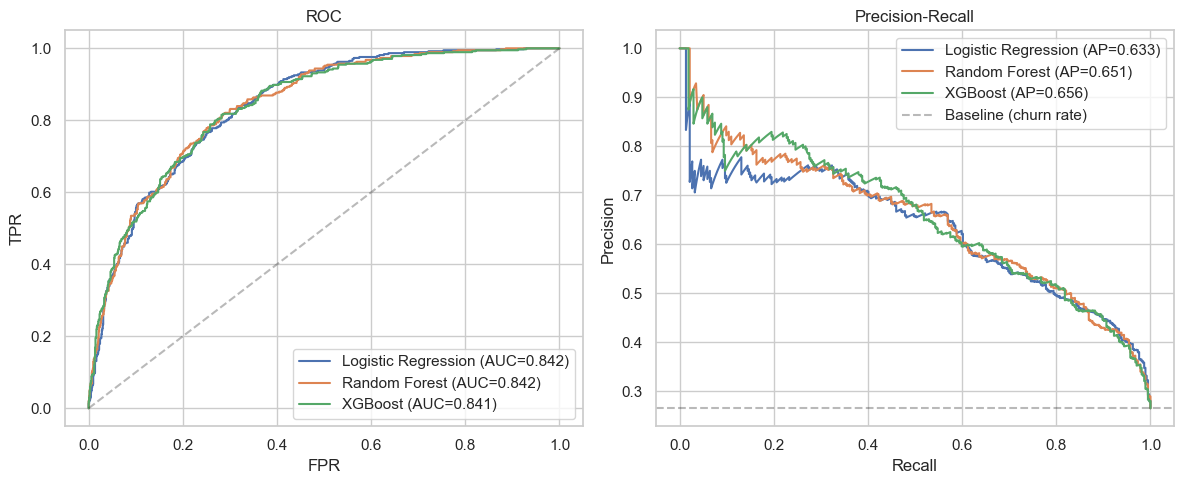

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, proba[name])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba[name]):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, proba[name])
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, proba[name]):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC")
axes[0].legend()
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.3, label="Baseline (churn rate)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("Precision-Recall")
axes[1].legend()
plt.tight_layout()
plt.show()

In [12]:
best_model_name = metrics_df["PR-AUC"].idxmax()
print(f"Mejor modelo por PR-AUC: {best_model_name}")
metrics_df.loc[[best_model_name]]

Mejor modelo por PR-AUC: XGBoost


,ROC-AUC,PR-AUC,Precision@20%,Recall@20%,Brier
Modelo,,,,,
XGBoost,0.8413,0.6556,0.6702,0.5053,0.1611


Se elige el modelo con **mayor PR-AUC** (no ROC-AUC ni accuracy) porque es la métrica que mejor refleja la capacidad de rankear correctamente a la minoría que hace churn — que es exactamente lo que la estrategia Top-K de la siguiente sección explota. El resultado impreso arriba fija `best_model_name`, usado en toda la sección de decisión.

## 7. Decisión óptima: ¿a quién intervenir?

Restricción de negocio: solo se puede intervenir al **20%** de los clientes. Costo de intervenir: **10**. Valor de retener a un cliente que sí se iba: **100**.

`Profit = 100 * (intervenidos que sí eran churn) - 10 * (total intervenidos)`

Estrategia: usar las probabilidades del mejor modelo (`best_model_name`) para rankear a los clientes de test por riesgo, y aplicar **Top-K = 20%** (no un threshold fijo), porque Top-K garantiza exactamente el 20% de intervenciones sin importar cómo se distribuyan las probabilidades — que es justo la restricción de recursos del enunciado.

In [13]:
def profit(y_true, intervened_mask, cost=10, value=100):
    """Profit = value * (correctly retained) - cost * (total intervened)."""
    retained = int(((y_true == 1) & intervened_mask).sum())
    n_intervened = int(intervened_mask.sum())
    return value * retained - cost * n_intervened, retained, n_intervened

# Self-check: reproduce the worked example from hack 3 (2).md
# rows: (proba, real, intervened) = (0.9, 1, True), (0.8, 0, True), (0.2, 1, False)
example_y = np.array([1, 0, 1])
example_mask = np.array([True, True, False])
example_profit, example_retained, example_n = profit(example_y, example_mask)
assert (example_profit, example_retained, example_n) == (80, 1, 2), \
    f"Expected profit=80 per hack 3 (2).md worked example, got {example_profit}"
print("Self-check OK: profit function matches worked example (profit=80).")

Self-check OK: profit function matches worked example (profit=80).


In [14]:
y_test_arr = y_test.values
scores = proba[best_model_name]
n = len(y_test_arr)
k = int(np.round(n * 0.20))

# Model-driven Top-K
top_idx = np.argsort(scores)[::-1][:k]
model_mask = np.zeros(n, dtype=bool)
model_mask[top_idx] = True
model_profit, model_retained, model_n = profit(y_test_arr, model_mask)

# Random baseline (same budget, seeded for reproducibility)
rng = np.random.default_rng(RANDOM_STATE)
random_idx = rng.choice(n, size=k, replace=False)
random_mask = np.zeros(n, dtype=bool)
random_mask[random_idx] = True
random_profit, random_retained, random_n = profit(y_test_arr, random_mask)

# Oracle: best possible size-k selection = the k actual churners with highest priority
# (if churners <= k, oracle intervenes on all churners; extra budget slots don't add profit)
n_churners = int(y_test_arr.sum())
oracle_mask = np.zeros(n, dtype=bool)
if n_churners <= k:
    oracle_mask[y_test_arr == 1] = True
else:
    oracle_mask[np.where(y_test_arr == 1)[0][:k]] = True
oracle_profit, oracle_retained, oracle_n = profit(y_test_arr, oracle_mask)

summary = pd.DataFrame([
    {"Estrategia": f"Modelo ({best_model_name}) Top-20%", "Clientes intervenidos": model_n,
     "Retenidos correctamente": model_retained, "Profit": model_profit},
    {"Estrategia": "Aleatorio (20%)", "Clientes intervenidos": random_n,
     "Retenidos correctamente": random_retained, "Profit": random_profit},
    {"Estrategia": "Oráculo (óptimo con presupuesto 20%)", "Clientes intervenidos": oracle_n,
     "Retenidos correctamente": oracle_retained, "Profit": oracle_profit},
]).set_index("Estrategia")
summary

,Clientes intervenidos,Retenidos correctamente,Profit
Estrategia,,,
Modelo (XGBoost) Top-20%,282,189,16080
Aleatorio (20%),282,74,4580
Oráculo (óptimo con presupuesto 20%),282,282,25380


**Variante threshold:** en vez de Top-K, se puede fijar un umbral de probabilidad e intervenir a quien lo supere. El problema es que un umbral fijo (p. ej. 0.7) no garantiza el 20% exacto — puede dar 10% o 50% según cómo se distribuyan los scores. Por eso se busca el umbral que sí reproduce el 20% (el cuantil 80 de los scores), y se verifica que coincide con la selección de Top-K.

In [15]:
threshold_20 = np.quantile(scores, 1 - 0.20)
threshold_mask = scores >= threshold_20
threshold_profit, threshold_retained, threshold_n = profit(y_test_arr, threshold_mask)

print(f"Umbral que produce ~20% de intervenidos: {threshold_20:.4f}")
print(f"Clientes intervenidos con threshold: {threshold_n} (vs. Top-K: {model_n})")
print(f"Profit con threshold: {threshold_profit} (vs. Top-K: {model_profit})")
assert abs(threshold_n - model_n) <= 1, "Threshold-based selection should match Top-K size (±1 due to ties)"

Umbral que produce ~20% de intervenidos: 0.7395
Clientes intervenidos con threshold: 282 (vs. Top-K: 282)
Profit con threshold: 16080 (vs. Top-K: 16080)


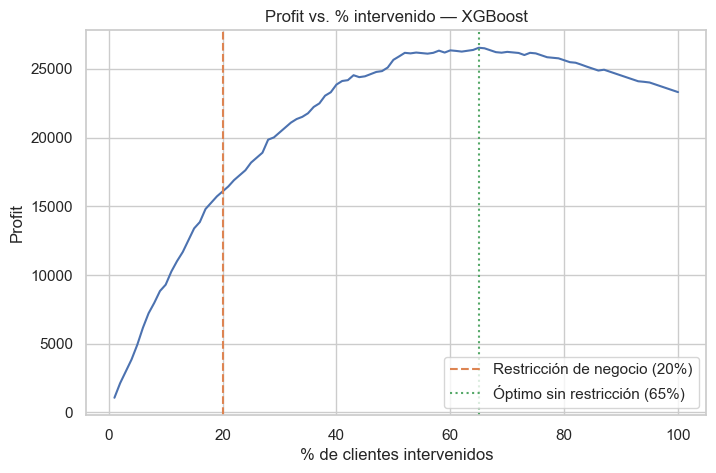

Profit al 20% (restricción de negocio): 16080
Profit máximo posible variando el %: 26540 en 65%


In [16]:
fracs = np.linspace(0.01, 1.0, 100)
profits = []
order = np.argsort(scores)[::-1]
for f in fracs:
    kk = max(1, int(np.round(n * f)))
    mask = np.zeros(n, dtype=bool)
    mask[order[:kk]] = True
    p, _, _ = profit(y_test_arr, mask)
    profits.append(p)

best_frac = fracs[int(np.argmax(profits))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fracs * 100, profits, color="#4C72B0")
ax.axvline(20, color="#DD8452", linestyle="--", label="Restricción de negocio (20%)")
ax.axvline(best_frac * 100, color="#55A868", linestyle=":",
           label=f"Óptimo sin restricción ({best_frac*100:.0f}%)")
ax.set_xlabel("% de clientes intervenidos")
ax.set_ylabel("Profit")
ax.set_title(f"Profit vs. % intervenido — {best_model_name}")
ax.legend()
plt.show()

print(f"Profit al 20% (restricción de negocio): {model_profit}")
print(f"Profit máximo posible variando el %: {max(profits):.0f} en {best_frac*100:.0f}%")

In [17]:
retained_ok = int(((y_test_arr == 1) & model_mask).sum())        # Retenido correctamente
wasted = int(((y_test_arr == 0) & model_mask).sum())              # Gasto en vano
lost = int(((y_test_arr == 1) & (~model_mask)).sum())              # Perdido
not_needed = int(((y_test_arr == 0) & (~model_mask)).sum())        # Correcto no-intervenir

business_summary = pd.DataFrame({
    "Categoría": ["Retenido (churn + intervenido)", "Gasto en vano (no-churn + intervenido)",
                  "Perdido (churn + no intervenido)", "Correcto no-intervenir (no-churn + no intervenido)"],
    "N° clientes": [retained_ok, wasted, lost, not_needed],
})
business_summary

,Categoría,N° clientes
0,Retenido (churn + intervenido),189
1,Gasto en vano (no-churn + intervenido),93
2,Perdido (churn + no intervenido),185
3,Correcto no-intervenir (no-churn + no interven...,942


## Conclusiones

- El modelo **XGBoost** (seleccionado por PR-AUC), combinado con una estrategia **Top-K = 20%**, produce un profit muy superior al baseline aleatorio con el mismo presupuesto, y se acerca al oráculo (techo teórico con ese mismo presupuesto) — ver tabla comparativa arriba.
- La variante por **threshold** (umbral = cuantil 80 de los scores) reproduce prácticamente la misma selección que Top-K, confirmando que ambas estrategias son equivalentes cuando el umbral se calibra exactamente al presupuesto disponible.
- La curva profit-vs-%intervenido muestra si el 20% fijado por la empresa es o no el punto de máximo profit sin restricciones — información directamente accionable para negociar el presupuesto de intervención.
- Detalle completo de cada decisión técnica en `DECISIONES.md`.